# Project Overview

This project analyzes a global retail dataset to identify trends in sales, profitability, and customer purchasing behavior.

The analysis includes data cleaning, feature engineering, data validation, and exploratory analysis using Python. The cleaned dataset is then used for SQL analysis and a Power BI dashboard.

# Data Loading

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("D:/Projects/super-store-orders/01_data_raw/SuperStoreOrders.csv")

In [9]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


# Initial Data Inspection

### Dataset Overview

In [10]:
print(df.shape)
print(df.columns.tolist())

(51290, 21)
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [12]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [13]:
df.isna().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

### Initial Observations

Initial inspection showed 51,290 rows and 21 columns. Key business fields include sales, profit, discount, shipping_cost, category, region, and order dates. The next step is to check date formatting, missing values, and duplicates before preparing the dataset for SQL and Power BI reporting.

# Data Cleaning

Before performing analysis, several data cleaning steps were applied to ensure the dataset was accurate and suitable for analysis.

The cleaning process included:

• Standardizing date formats and converting date columns to datetime  
• Creating a shipping duration feature based on order and shipment dates  
• Validating numeric columns used for calculations  
• Handling missing values in key fields such as sales  
• Recalculating derived metrics after cleaning  
• Checking for duplicate records  

These steps help ensure that calculations, aggregations, and visualizations are based on reliable data.

### Clean column names

In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [15]:
print(df.columns.tolist())

['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']


### Date Parsing and Standardization

The raw order_date and ship_date columns contained mixed date separators (both / and -). This caused issues when converting the columns to datetime format.

To resolve this, the date strings were standardized by replacing dash separators with slashes, allowing the columns to be parsed consistently using the d/m/yyyy format.

After standardization, the datetime conversion was validated to ensure no records were lost.

In [16]:
# Standardize date separators
df["order_date"] = df["order_date"].astype(str).str.strip().str.replace("-", "/", regex=False)
df["ship_date"] = df["ship_date"].astype(str).str.strip().str.replace("-", "/", regex=False)

# Convert to datetime
df["order_date"] = pd.to_datetime(df["order_date"], format="%d/%m/%Y", errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], format="%d/%m/%Y", errors="coerce")

# Validation check
print("order_date missing:", df["order_date"].isna().sum())
print("ship_date missing:", df["ship_date"].isna().sum())

print(df[["order_date", "ship_date"]].head(10))
print(df[["order_date", "ship_date"]].dtypes)

order_date missing: 0
ship_date missing: 0
  order_date  ship_date
0 2011-01-01 2011-01-06
1 2011-01-01 2011-01-08
2 2011-01-01 2011-01-05
3 2011-01-01 2011-01-05
4 2011-01-01 2011-01-08
5 2011-01-01 2011-01-08
6 2011-01-02 2011-01-06
7 2011-01-03 2011-01-03
8 2011-01-03 2011-01-09
9 2011-01-03 2011-01-07
order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object


### Shipping Duration Feature Creation

In [17]:
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

df[["order_date", "ship_date", "shipping_days"]].head(10)

,order_date,ship_date,shipping_days
0,2011-01-01,2011-01-06,5
1,2011-01-01,2011-01-08,7
2,2011-01-01,2011-01-05,4
3,2011-01-01,2011-01-05,4
4,2011-01-01,2011-01-08,7
5,2011-01-01,2011-01-08,7
6,2011-01-02,2011-01-06,4
7,2011-01-03,2011-01-03,0
8,2011-01-03,2011-01-09,6
9,2011-01-03,2011-01-07,4


### Shipping Logic Validation

A data quality check was performed on the shipping_days field to identify any negative values or unusually large shipping times. This helps confirm that the order and shipment dates are logically consistent before moving into analysis.

In [18]:
print("Negative shipping days:", (df["shipping_days"] < 0).sum())
print("Maximum shipping days:", df["shipping_days"].max())
print("Minimum shipping days:", df["shipping_days"].min())

Negative shipping days: 0
Maximum shipping days: 7
Minimum shipping days: 0


### Date-Based Feature Engineering

Additional time-based columns were created from the order_date field to support trend analysis in Python, SQL, and Power BI. These fields will make it easier to analyze sales and profit by month and over time.

In [19]:
df["order_month"] = df["order_date"].dt.month
df["order_month_name"] = df["order_date"].dt.month_name()
df["order_year"] = df["order_date"].dt.year
df["order_year_month"] = df["order_date"].dt.to_period("M").astype(str)

df[["order_date", "order_month", "order_month_name", "order_year", "order_year_month"]].head(10)

,order_date,order_month,order_month_name,order_year,order_year_month
0,2011-01-01,1,January,2011,2011-01
1,2011-01-01,1,January,2011,2011-01
2,2011-01-01,1,January,2011,2011-01
3,2011-01-01,1,January,2011,2011-01
4,2011-01-01,1,January,2011,2011-01
5,2011-01-01,1,January,2011,2011-01
6,2011-01-02,1,January,2011,2011-01
7,2011-01-03,1,January,2011,2011-01
8,2011-01-03,1,January,2011,2011-01
9,2011-01-03,1,January,2011,2011-01


### Numeric Column Validation

Key numeric columns were reviewed to confirm that sales, quantity, discount, profit, and shipping cost were stored in the correct format for analysis.

In [20]:
numeric_cols = ["sales", "quantity", "discount", "profit", "shipping_cost", "year"]

print(df[numeric_cols].dtypes)
print(df[numeric_cols].describe())

sales             object
quantity           int64
discount         float64
profit           float64
shipping_cost    float64
year               int64
dtype: object
           quantity      discount        profit  shipping_cost          year
count  51290.000000  51290.000000  51290.000000   51290.000000  51290.000000
mean       3.476545      0.142908     28.641740      26.375915   2012.777208
std        2.278766      0.212280    174.424113      57.296804      1.098931
min        1.000000      0.000000  -6599.978000       0.000000   2011.000000
25%        2.000000      0.000000      0.000000       2.610000   2012.000000
50%        3.000000      0.000000      9.240000       7.790000   2013.000000
75%        5.000000      0.200000     36.810000      24.450000   2014.000000
max       14.000000      0.850000   8399.976000     933.570000   2014.000000


### Numeric Type Conversion

In [21]:
for sales in numeric_cols:
    df[sales] = pd.to_numeric(df[sales], errors="coerce")

In [22]:
print(df[numeric_cols].dtypes)

sales            float64
quantity           int64
discount         float64
profit           float64
shipping_cost    float64
year               int64
dtype: object


### Profitability and Discount Features

New analytical fields were created to support profitability analysis. Profit margin was calculated to measure profit relative to sales, and a discount flag was added to separate discounted orders from non-discounted orders.

In [23]:
df["profit_margin"] = np.where(df["sales"] != 0, df["profit"] / df["sales"], 0)
df["discount_flag"] = np.where(df["discount"] > 0, "Discounted", "No Discount")

df[["sales", "profit", "profit_margin", "discount", "discount_flag"]].head(10)

,sales,profit,profit_margin,discount,discount_flag
0,408.0,106.140,0.260147,0.0,No Discount
1,120.0,36.036,0.300300,0.1,Discounted
2,66.0,29.640,0.449091,0.0,No Discount
3,45.0,-26.055,-0.579000,0.5,Discounted
4,114.0,37.770,0.331316,0.1,Discounted
5,55.0,15.342,0.278945,0.1,Discounted
6,314.0,3.120,0.009936,0.0,No Discount
7,276.0,110.412,0.400043,0.1,Discounted
8,912.0,-319.464,-0.350289,0.4,Discounted
9,667.0,253.320,0.379790,0.0,No Discount


In [24]:
print("Max profit margin:", df["profit_margin"].max())
print("Min profit margin:", df["profit_margin"].min())

Max profit margin: 0.5828
Min profit margin: -4.727752066115702


# Data Quality Checks

### Negative Profit Detection

A data quality review was performed on the profit column to identify orders with negative profit. Negative profit does not necessarily indicate bad data, but it may highlight products, regions, or discount strategies that are hurting profitability.

In [25]:
print("Orders with negative profit:", (df["profit"] < 0).sum())

negative_profit_orders = df[df["profit"] < 0]

negative_profit_orders[[
    "order_id",
    "order_date",
    "customer_name",
    "category",
    "sub_category",
    "product_name",
    "sales",
    "discount",
    "profit"
]].head(10)

Orders with negative profit: 12543


,order_id,order_date,customer_name,category,sub_category,product_name,sales,discount,profit
3,IT-2011-3647632,2011-01-01,Eugene Moren,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,0.50,-26.0550
8,ID-2011-80230,2011-01-03,Ken Lonsdale,Technology,Copiers,"Hewlett Wireless Fax, Laser",912.0,0.40,-319.4640
10,IN-2011-65159,2011-01-03,Larry Blacks,Office Supplies,Storage,"Tenex Lockers, Industrial",338.0,0.45,-122.8005
11,IN-2011-65159,2011-01-03,Larry Blacks,Furniture,Tables,"Chromcraft Round Table, Adjustable Height",211.0,0.55,-70.3995
14,ID-2011-80230,2011-01-03,Ken Lonsdale,Furniture,Chairs,"Hon Rocking Chair, Set of Two",159.0,0.40,-95.6760
18,ID-2011-80230,2011-01-03,Ken Lonsdale,Furniture,Chairs,"SAFCO Chairmat, Black",69.0,0.40,-26.4120
19,ID-2011-12596,2011-01-03,Chris McAfee,Office Supplies,Storage,"Smead File Cart, Blue",135.0,0.47,-45.9018
33,US-2011-136007,2011-01-04,Beth Thompson,Office Supplies,Envelopes,"Jiffy Interoffice Envelope, Set of 50",74.0,0.60,-107.8560
37,IT-2011-2942451,2011-01-04,Grant Thornton,Office Supplies,Art,"Boston Markers, Easy-Erase",27.0,0.50,-21.9000
40,IT-2011-2942451,2011-01-04,Grant Thornton,Office Supplies,Storage,"Eldon Folders, Single Width",17.0,0.50,-1.0500


### Extreme Discount Review

Discount values were reviewed to identify unusually high discount levels that could have a strong impact on profitability. This check helps determine whether aggressive discounting may be contributing to losses.

In [26]:
print(df["discount"].describe())

print("Max discount:", df["discount"].max())
print("Min discount:", df["discount"].min())
print("Orders with discount above 0.5:", (df["discount"] > 0.5).sum())

count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: discount, dtype: float64
Max discount: 0.85
Min discount: 0.0
Orders with discount above 0.5: 4172


In [27]:
high_discount_orders = df[df["discount"] > 0.5]

high_discount_orders[[
    "order_id",
    "order_date",
    "category",
    "sub_category",
    "product_name",
    "sales",
    "discount",
    "profit"
]].head(10)

,order_id,order_date,category,sub_category,product_name,sales,discount,profit
11,IN-2011-65159,2011-01-03,Furniture,Tables,"Chromcraft Round Table, Adjustable Height",211.0,0.55,-70.3995
33,US-2011-136007,2011-01-04,Office Supplies,Envelopes,"Jiffy Interoffice Envelope, Set of 50",74.0,0.60,-107.8560
49,CA-2011-112326,2011-01-05,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,4.0,0.80,-5.4870
85,IT-2011-4546695,2011-01-08,Furniture,Bookcases,"Ikea Classic Bookcase, Metal",987.0,0.60,-1011.6360
87,CA-2011-105417,2011-01-08,Furniture,Furnishings,"Howard Miller 14-1/2"" Diameter Chrome Round Wa...",77.0,0.60,-53.7096
90,NI-2011-4770,2011-01-08,Office Supplies,Binders,"Avery Index Tab, Economy",5.0,0.70,-4.5420
91,CA-2011-105417,2011-01-08,Office Supplies,Binders,Acco Four Pocket Poly Ring Binder with Label H...,10.0,0.80,-18.2525
132,ES-2011-4359424,2011-01-11,Furniture,Tables,"Bevis Training Table, with Bottom Storage",268.0,0.60,-341.7360
136,TU-2011-800,2011-01-11,Furniture,Bookcases,"Safco Floating Shelf Set, Metal",157.0,0.60,-117.7200
156,NI-2011-1670,2011-01-12,Office Supplies,Storage,"Fellowes Folders, Wire Frame",15.0,0.70,-22.4580


In [28]:
high_discount_summary = (
    df[df["discount"] > 0.5]
    .groupby("category")
    .agg(
        high_discount_order_count=("discount", "count"),
        avg_discount=("discount", "mean"),
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum")
    )
    .reset_index()
)

high_discount_summary

,category,high_discount_order_count,avg_discount,total_sales,total_profit
0,Furniture,835,0.632982,125556.0,-159554.47860
1,Office Supplies,2677,0.668547,94644.0,-131788.90860
2,Technology,660,0.647418,83894.0,-121238.27056


### Shipping Duration Validation

Shipping duration was calculated as the number of days between order_date and ship_date.

A validation check was performed to identify negative values and unusually long delivery times. No negative shipping durations were found, and the maximum shipping time observed in the dataset was 7 days.

This indicates that the order and shipment dates are logically consistent and suitable for further analysis.

In [29]:
print("Negative shipping days:", (df["shipping_days"] < 0).sum())
print("Maximum shipping days:", df["shipping_days"].max())
print("Minimum shipping days:", df["shipping_days"].min())
print(df["shipping_days"].describe())

Negative shipping days: 0
Maximum shipping days: 7
Minimum shipping days: 0
count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: shipping_days, dtype: float64


### Missing Value Review

A review of missing values was performed across all columns to identify potential data quality issues that could affect analysis. 

Understanding where missing values exist helps determine whether additional cleaning steps are necessary before performing aggregations, calculations, or visualizations.

In [30]:
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values

profit_margin       2630
sales               2630
order_id               0
order_date             0
customer_name          0
segment                0
state                  0
country                0
market                 0
region                 0
ship_date              0
ship_mode              0
category               0
product_id             0
product_name           0
sub_category           0
discount               0
profit                 0
shipping_cost          0
quantity               0
order_priority         0
year                   0
order_month            0
shipping_days          0
order_month_name       0
order_year             0
order_year_month       0
discount_flag          0
dtype: int64

In [31]:
missing_values[missing_values > 0]

profit_margin    2630
sales            2630
dtype: int64

In [32]:
print("Missing sales:", df["sales"].isna().sum())
print("Missing profit_margin:", df["profit_margin"].isna().sum())

Missing sales: 2630
Missing profit_margin: 2630


### Handling Missing Sales Values

The missing value review identified 2,630 records with missing values in the sales column. Since sales is a core metric used in profitability and revenue analysis, these records cannot be used reliably for calculations such as profit margin or sales aggregation.

To maintain data integrity for analysis, records with missing sales values were removed from the dataset.

In [33]:
before_rows = len(df)

df = df.dropna(subset=["sales"])

after_rows = len(df)

print("Rows before removal:", before_rows)
print("Rows after removal:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removal: 51290
Rows after removal: 48660
Rows removed: 2630


### Recalculate Profit Margin

After removing records with missing sales values, derived metrics were recalculated to ensure that all analytical fields reflect the cleaned dataset.

Profit margin was recalculated as profit divided by sales. This metric will be used later to evaluate product and category profitability.

In [34]:
df["profit_margin"] = np.where(df["sales"] != 0, df["profit"] / df["sales"], 0)

### Profit Margin Validation

After recalculating profit_margin, a validation check was performed to confirm that the values fall within a reasonable range. 

This step helps identify potential calculation issues or extreme values that may impact profitability analysis.

In [35]:
print("Max profit margin:", df["profit_margin"].max())
print("Min profit margin:", df["profit_margin"].min())

df[["sales", "profit", "profit_margin"]].describe()

Max profit margin: 0.5828
Min profit margin: -4.727752066115702


,sales,profit,profit_margin
count,48660.000000,48660.000000,48660.000000
mean,161.017838,14.688249,0.041939
std,201.092519,86.825672,0.474655
min,0.000000,-1924.542000,-4.727752
25%,29.000000,0.000000,0.000000
50%,77.000000,8.460000,0.168446
75%,208.000000,31.154400,0.334452
max,999.000000,486.600000,0.582800


### Duplicate Record Check

In [47]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


No duplicate rows were identified in the dataset, confirming that each record represents a unique transaction entry.

# Exploratory Data Analysis

## Business Performance Overview

With the dataset cleaned and validated, exploratory data analysis was performed to better understand sales performance, profitability, product trends, and customer purchasing behavior.

This section examines overall business performance, category and sub-category profitability, the impact of discounts on profit margins, regional sales patterns, time-based sales trends, top customers by revenue, and shipping duration patterns. 

The goal of this analysis is to identify key trends and insights that can support data-driven business decisions and inform the SQL analysis and Power BI dashboard.

### Overall Sales and Profit Overview

To understand the overall scale of the business in the dataset, total sales, total profit, and total orders were calculated. These high-level metrics provide a quick summary of business performance before examining more detailed breakdowns.

In [48]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)

Total Sales: 7835128.0
Total Profit: 714730.17
Total Orders: 24386


### Average Revenue per Order

In [49]:
average_revenue_per_order = df["sales"].sum() / df["order_id"].nunique()

print("Average Revenue per Order:", round(average_revenue_per_order, 2))

Average Revenue per Order: 321.3


### Average Profit per Order

In [50]:
average_profit_per_order = df["profit"].sum() / df["order_id"].nunique()

print("Average Profit per Order:", round(average_profit_per_order, 2))

Average Profit per Order: 29.31


### Category Performance Analysis

Sales and profit were analyzed by product category to understand which categories contribute the most revenue and profitability. This helps identify high-performing areas of the business as well as categories that may require improvement.

In [51]:
category_summary = (
    df.groupby("category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

category_summary

,category,total_sales,total_profit,order_count
1,Office Supplies,2790258.0,350107.32450,18806
2,Technology,2638265.0,267573.47238,7551
0,Furniture,2406605.0,97049.37790,7519


### Profit Margin by Category

In [52]:
category_summary["profit_margin"] = (
    category_summary["total_profit"] /
    category_summary["total_sales"]
)

In [53]:
category_summary

,category,total_sales,total_profit,order_count,profit_margin
1,Office Supplies,2790258.0,350107.32450,18806,0.125475
2,Technology,2638265.0,267573.47238,7551,0.101420
0,Furniture,2406605.0,97049.37790,7519,0.040326


### Average Order Value by Category

In [54]:
aov_by_category = (
    df.groupby("category")
    .agg(
        avg_order_value=("sales", "mean"),
        avg_profit=("profit", "mean")
    )
    .reset_index()
)

aov_by_category

,category,avg_order_value,avg_profit
0,Furniture,270.222883,10.897078
1,Office Supplies,90.781429,11.390790
2,Technology,292.555445,29.671044


Office Supplies generates the highest number of orders, indicating strong demand for everyday business products. Technology produces high revenue per order, while Furniture shows lower profitability relative to sales, suggesting potential discount or cost pressures in that category.

### Profitability by Sub-Category

A deeper profitability analysis was performed at the sub-category level to identify specific product groups that generate strong profits or contribute to losses.

In [55]:
subcategory_profit = (
    df.groupby("sub_category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum")
    )
    .reset_index()
    .sort_values("total_profit", ascending=False)
)

subcategory_profit

,sub_category,total_sales,total_profit
6,Copiers,782710.0,85220.44908
0,Accessories,570054.0,81507.85580
13,Phones,870518.0,78170.20510
14,Storage,913499.0,74684.47350
5,Chairs,927982.0,68377.74450
12,Paper,244307.0,59207.68270
2,Art,371050.0,57842.60850
4,Bookcases,811505.0,53580.68990
3,Binders,346130.0,48538.11600
9,Furnishings,377432.0,45012.21550


### Discount Impact on Profitability

Discount levels were analyzed to evaluate their impact on profitability. While discounts can help drive sales volume, excessive discounting may reduce profit margins or contribute to negative profit outcomes.

This analysis compares sales, profit, and average profit margin for discounted and non-discounted orders.

In [56]:
discount_analysis = (
    df.groupby("discount_flag")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        avg_profit_margin=("profit_margin", "mean")
    )
    .reset_index()
)

discount_analysis

,discount_flag,total_sales,total_profit,avg_profit_margin
0,Discounted,3556730.0,-3.578507e+05,-0.250280
1,No Discount,4278398.0,1.072581e+06,0.265736


Orders with discounts tend to produce significantly lower profit margins, indicating that aggressive discounting may contribute to negative profit outcomes.

## Sales Trends

### Monthly Sales Trends

Sales trends were analyzed over time to understand how revenue changes across different months. Identifying seasonal patterns or growth trends can help businesses plan inventory, marketing, and staffing.

In [57]:
monthly_sales = (
    df.groupby("order_year_month")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum")
    )
    .reset_index()
)

monthly_sales.head(10)

,order_year_month,total_sales,total_profit
0,2011-01,64363.0,3857.14052
1,2011-02,60848.0,5126.20778
2,2011-03,78983.0,7394.58030
3,2011-04,80698.0,6719.46738
4,2011-05,91536.0,5133.88400
5,2011-06,142526.0,9528.76554
6,2011-07,75412.0,4070.57182
7,2011-08,132065.0,13841.75724
8,2011-09,153992.0,14391.33644
9,2011-10,122853.0,11661.53748


To improve readability of the monthly sales trend chart, the x-axis labels were reduced so that only a subset of months are displayed. This prevents label overlap and makes the trend easier to interpret.

In [58]:
monthly_sales["order_year_month"] = pd.to_datetime(monthly_sales["order_year_month"])

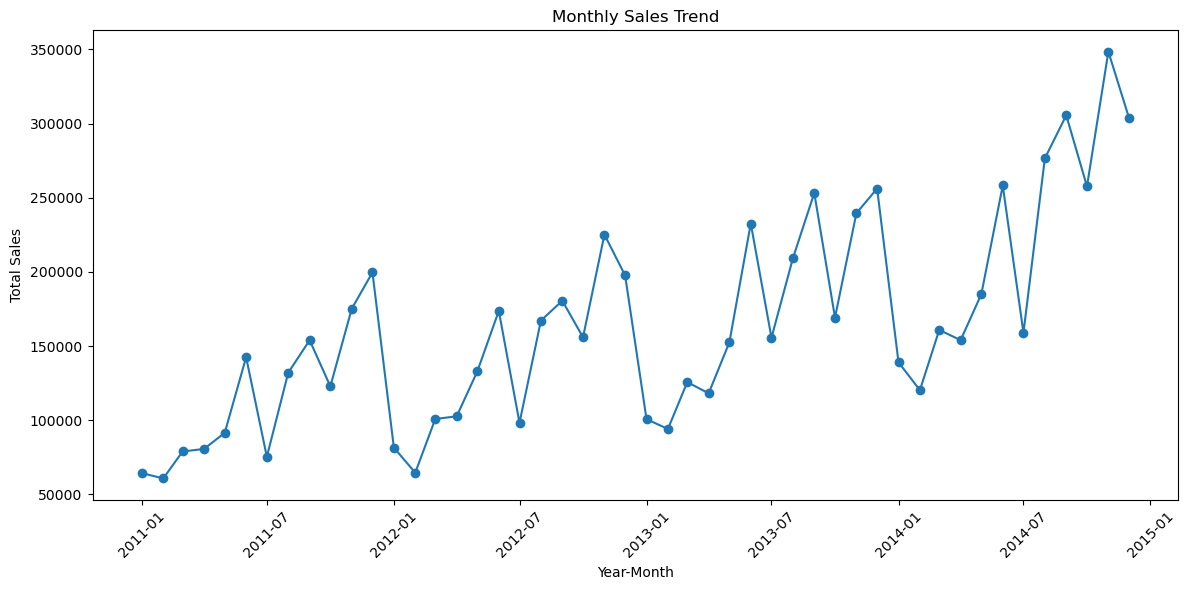

In [59]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales["order_year_month"], monthly_sales["total_sales"], marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Sales show noticeable fluctuations across months, indicating potential seasonal demand patterns. Further analysis in the dashboard will explore whether specific product categories or regions contribute to these variations.

## Regional Performance

### Regional Sales Performance

Sales performance was analyzed across regions to identify geographic areas that contribute the most revenue and profit.

In [60]:
region_summary = (
    df.groupby("region")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

region_summary

,region,total_sales,total_profit,order_count
3,Central,1806638.0,168764.86940,5113
10,South,1031101.0,63754.84690,3198
7,North,790546.0,106622.10832,2275
9,Oceania,625382.0,54548.28600,1676
5,EMEA,575562.0,11810.25900,2435
0,Africa,538115.0,30140.61900,2195
11,Southeast Asia,532172.0,-7768.49810,1464
8,North Asia,453686.0,86676.69300,1101
12,West,424173.0,57373.85650,1574
4,Central Asia,389506.0,66450.97000,981


## Customer Insights

### Top Customers by Sales

Customer purchasing behavior was analyzed to identify the customers generating the highest sales. Understanding top customers can help businesses prioritize relationship management and retention strategies.

In [61]:
top_customers = (
    df.groupby("customer_name")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_customers

,customer_name,total_sales,total_profit,total_orders
263,Eric Murdock,19489.0,2450.54748,43
386,John Grady,19483.0,2870.44010,40
487,Maria Etezadi,18237.0,1822.93410,40
741,Theone Pippenger,17416.0,1859.91698,41
191,Dan Reichenbach,16705.0,1984.39860,40
77,Ben Ferrer,16661.0,2358.05394,37
621,Randy Bradley,16399.0,2429.66442,39
502,Mathew Reese,16125.0,3105.12260,28
552,Muhammed Yedwab,16091.0,488.46508,39
716,Steven Ward,15984.0,1217.34060,37


## Operational Metrics

### Shipping Duration Distribution

Shipping duration was analyzed to understand how long orders typically take to ship. 
Reviewing the distribution of shipping times helps identify whether most orders fall within a standard delivery window or if there are delays affecting fulfillment performance.

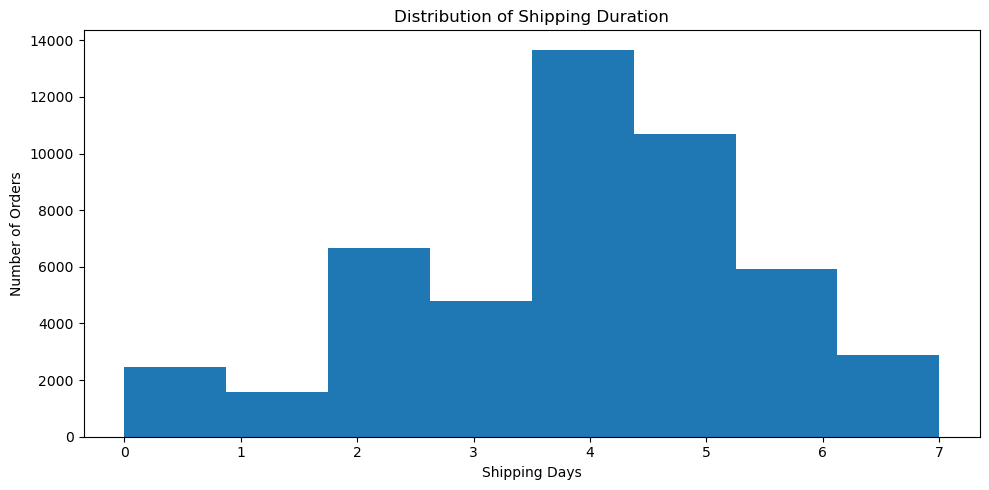

In [62]:
plt.figure(figsize=(10,5))

plt.hist(df["shipping_days"], bins=8)

plt.title("Distribution of Shipping Duration")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

Insights from this analysis will guide the SQL queries and visualizations built in the Power BI dashboard.

# Export Clean Dataset for SQL and Power BI

After completing the data cleaning and exploratory analysis steps, the cleaned dataset was exported as a CSV file. This file will be used for the SQL analysis stage and for building the Power BI dashboard.

In [65]:
df.to_csv(r"D:\Projects\super-store-orders\02_clean_data\superstore_cleaned.csv", index=False)

In [64]:
print("Clean dataset successfully exported.")

Clean dataset successfully exported.
